The code below uses provided data files:
NHTS.xlsx
NGSIM.xlsx

In [3]:
## import all needed packages at start of code
!pip install openpyxl
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Decide what plot style we want to use
sns.set_style('whitegrid')
sns.set_palette('deep')

# Load the Excel files
nhts_data = pd.read_excel('NHTS.xlsx', engine='openpyxl')
ngsim_data = pd.read_excel('NGSIM.xlsx', engine='openpyxl')

# Check that files loaded correctly and print columns
print("NHTS shape", nhts_data.shape)
print("NGSIM shape:", ngsim_data.shape)

print("\nNHTS columns:")
print(list(nhts_data.columns))

print("\nNGSIM columns:")
print(list(ngsim_data.columns))


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


NHTS shape (14684, 23)
NGSIM shape: (8166, 8)

NHTS columns:
['household_id', 'census_division', 'census_region', 'driver_count', 'household_income', 'household_size', 'household_workers', 'home_type', 'household_location', 'number_adults_household', 'vehicles_per_household', 'travel_date', 'travel_day', 'urban', 'vehicle_type', 'hybrid', 'make', 'vehicle_age', 'vehicle_commercial', 'vehicle_delivery', 'vehicle_rideshare', 'fuel_type', 'vehicle_year']

NGSIM columns:
['Time', 'leader_position(m)', 'follower_position(m)', 'leader_speed(m/s)', 'follower_speed(m/s)', 'leader_acc(m/s^2)', 'follower_acc(m/s^2)', 'trajectory_number']


1. Bar chart comparing categories within a specific variable

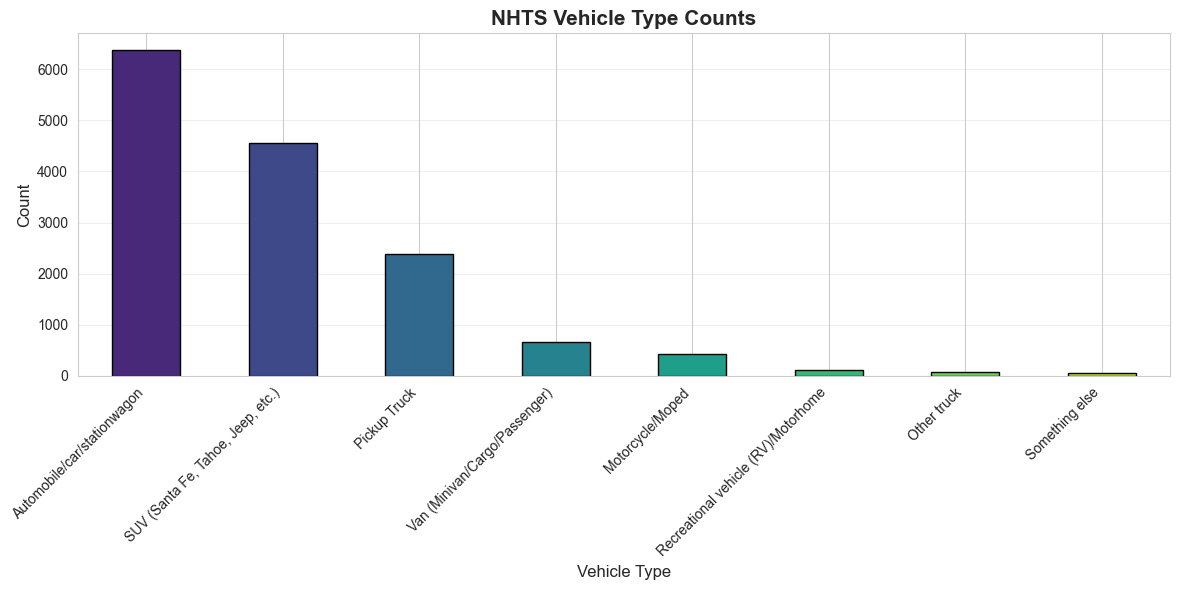

In [8]:
# Bar chart: number of records by vehicle type

vehicle_type_counts = nhts_data['vehicle_type'].value_counts().dropna()

plt.figure(figsize=(12,6))
veicle_type_counts.plot(
    kind='bar',
    color=sns.color_palette('viridis', len(vehicle_type_counts)),
    edgecolor='black'
)

plt.title('NHTS Vehicle Type Counts', fontsize=15, fontweight='bold')
plt.xlabel('Vehicle Type', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

2. Histogram showing the distribution of a specific variable

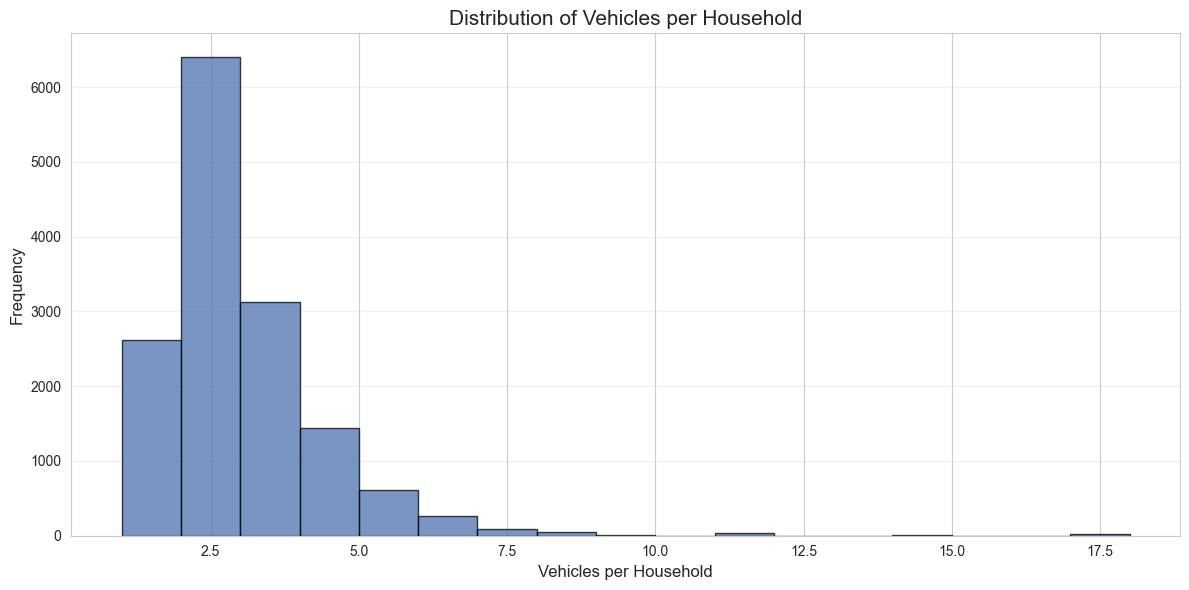

In [10]:
# Histogram: vehicles per household

plt.figure(figsize=(12,6))
plt.hist(
    nhts_data['vehicles_per_household'].dropna(),
    bins=range(1, int(nhts_data['vehicles_per_household'].max()) + 2),
    edgecolor='black',
    alpha=0.75
)

plt.title('Distribution of Vehicles per Household', fontsize=15)
plt.xlabel('Vehicles per Household', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

3. Boxplot showing the distribution of a variable in each category

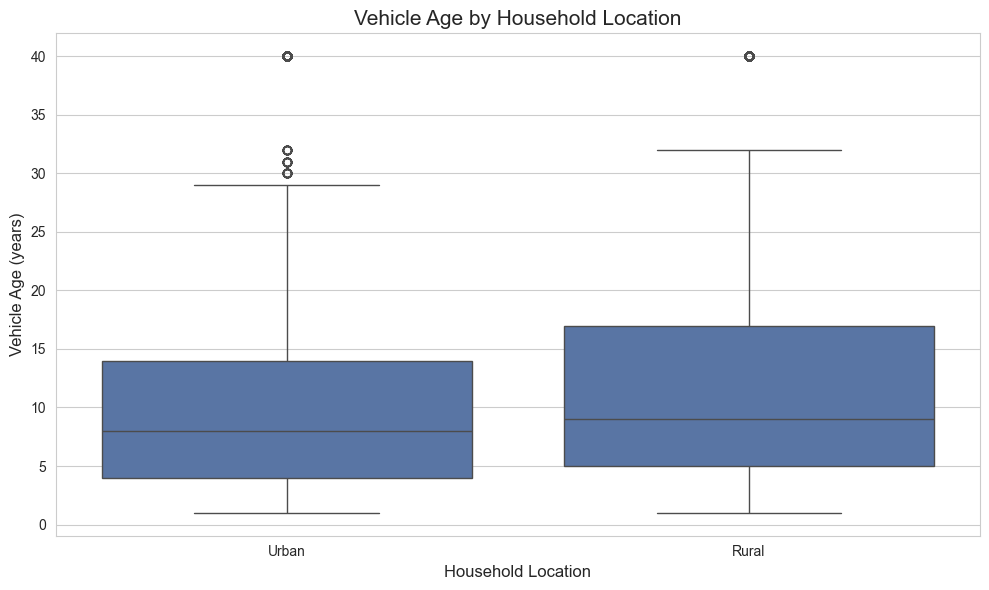

In [11]:
# Boxplot: vehicle age by household location

boxplot_df = nhts_data.dropna(subset=['vehicle_age', 'household_location']).copy()

plt.figure(figsize=(10,6))
sns.boxplot(
    data=boxplot_df,
    x='household_location',
    y='vehicle_age'
)

plt.title('Vehicle Age by Household Location', fontsize=15)
plt.xlabel('Household Location', fontsize=12)
plt.ylabel('Vehicle Age (years)', fontsize=12)
plt.tight_layout()
plt.show()

4. Time-series plot #1

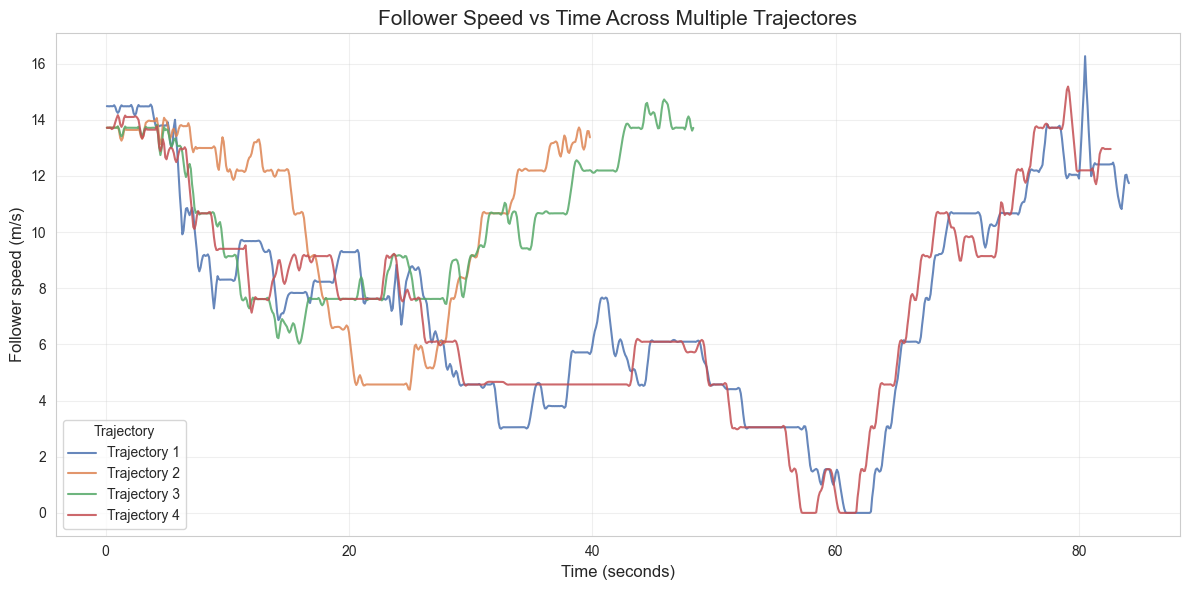

In [12]:
# Time-series: follower speed over time for multiple trajectory pairs

trajectory_numbers = [1, 2, 3, 4]

plt.figure(figsize=(12, 6))

for traj in trajectory_numbers:
    subset = ngsim_data[ngsim_data['trajectory_number'] == traj]
    plt.plot(
    subset['Time'].values,
    subset['follower_speed(m/s)'].values,
    linewidth=1.5,
    label=f'Trajectory {traj}', 
    alpha=0.85
    )

plt.title('Follower Speed vs Time Across Multiple Trajectores', fontsize=15)
plt.xlabel('Time (seconds)', fontsize=12)
plt.ylabel('Follower speed (m/s)', fontsize=12)
plt.legend(title='Trajectory')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

5. Time-series plot #2

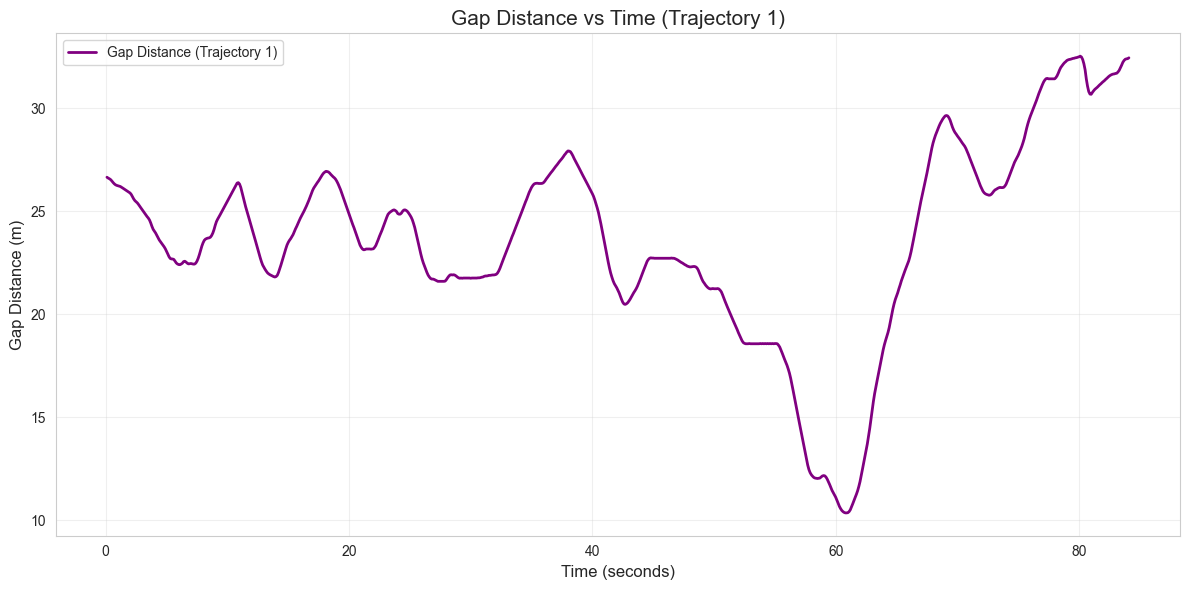

In [14]:
# Time-Series plot #2: gap distance over time for one trajectory pair

trajectory_number = 1
data_subset = ngsim_data[ngsim_data['trajectory_number'] == trajectory_number].copy()

gap_distance = (
    data_subset['leader_position(m)'].values
    - data_subset['follower_position(m)'].values
)

plt.figure(figsize=(12, 6))
plt.plot(
    data_subset['Time'].values,
    gap_distance, 
    color='purple',
    linewidth=2,
label=f'Gap Distance (Trajectory {trajectory_number})'
)

plt.title(f'Gap Distance vs Time (Trajectory {trajectory_number})', fontsize=15)
plt.xlabel('Time (seconds)', fontsize=12)
plt.ylabel('Gap Distance (m)', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

6. Customized matplot/seaborn plot

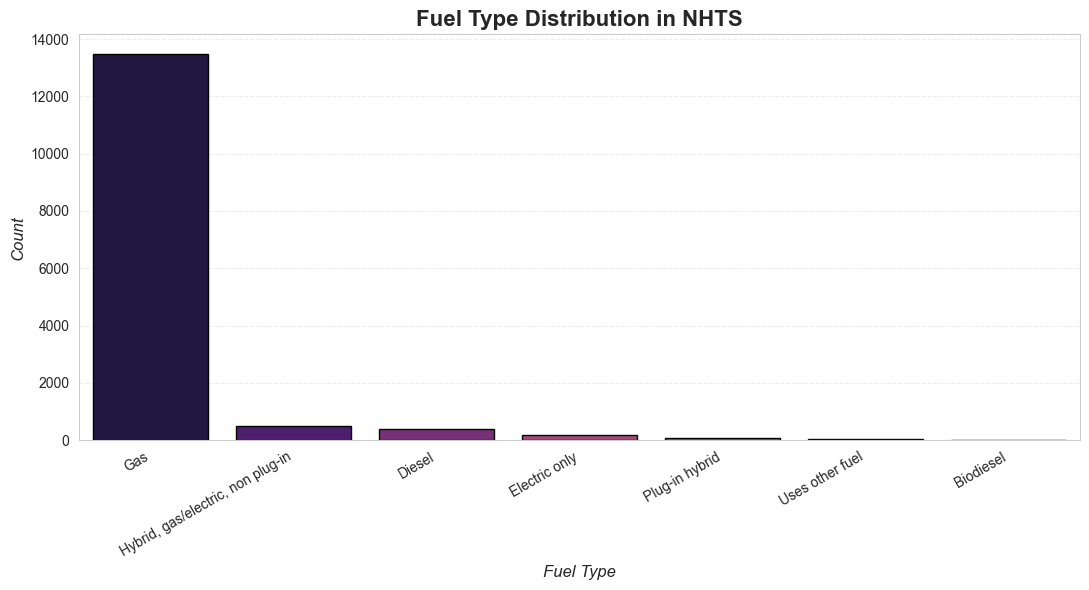

In [16]:
# Customized plot to show clear matplotlib/seaborn formatting changes

fuel_counts = nhts_data['fuel_type'].value_counts().dropna()

plt.figure(figsize=(11, 6))
sns.barplot(
    x=fuel_counts.index,
    y=fuel_counts.values,
    hue=fuel_counts.index,
    dodge=False,
    palette='magma',
    edgecolor='black'
)

plt.title('Fuel Type Distribution in NHTS', fontsize=16, fontweight='bold')
plt.xlabel('Fuel Type', fontsize=12, fontstyle='italic')
plt.ylabel('Count', fontsize=12, fontstyle='italic')
plt.xticks(rotation=30, ha='right')
plt.legend([], [], frameon=False)
plt.grid(axis='y', linestyle='--', alpha=0.35)
plt.tight_layout()
plt.show()

7. Intelligent Driver Model (IDM) Simulation Study

In [17]:
def idm_acceleraion(v, s, delta_v, v0, s0, T, a, b, delta):
    '''
    v = follower speed (m/s)
    s = gap distance (m)
    delta_v = follower speed - leader speed (m/s)
    v0 = desired speed (m/s)
    s0 = minimum spacing (m)
    T = desired time headway (s)
    a = maximum acceleration (m/s^2)
    b = comfortable deceleration (m/s^2)
    delta = acceleration exponent
    '''
    s = max(s, 0.1)
    s_star = s0 + v * T + (v * delta_v) / (2 * np.sqrt(a * b))
    s_star = max(s_star, s0)

    acceleration = a * (1 - (v / v0)**delta - (s_star / s)**2)
    return acceleration

In [19]:
# Choose one trajectory and extrace leader/ follower data

trajectory_number = 1
pair_df = ngsim_data[ngsim_data['trajectory_number'] == trajectory_number].reset_index(drop=True)

time_data = pair_df['Time'].values
leader_x = pair_df['leader_position(m)'].values
leader_v = pair_df['leader_speed(m/s)'].values
leader_a = pair_df['follower_acc(m/s^2)'].values

dt = np.median(np.diff(time_data))

print(f"Selected trajectory: {trajectory_number}")
print(f"Number of time steps: {len(time_data)}")
print(f"Estimated dt: {dt:.3f} s")

Selected trajectory: 1
Number of time steps: 841
Estimated dt: 0.100 s


In [22]:
# IDM parameters
v0 = 30.0        # desired velocity (m/s)
s0 = 2.0         # minimum spacing (m)
T = 1.5          # desired time headway (s)
a_param = 1.0    # max acceleration (m/s^2)
b = 1.5          # comfortable deceleration (m/s^2)
delta = 4        # exponent

def idm_acceleration(v, s, delta_v, v0, s0, T, a, b, delta):
    s = max(s, 0.1)

    s_star = s0 + v * T + (v * delta_v) / (2 * np.sqrt(a * b))
    s_star = max(s_star, s0)

    acceleration = a * (1 - (v / v0)**delta - (s_star / s)**2)
    return acceleration

n_steps = len(time_data)

sim_position = np.zeros(n_steps)
sim_speed = np.zeros(n_steps)
sim_acc = np.zeros(n_steps)

pair_df = ngsim_data[ngsim_data['trajectory_number'] == trajectory_number].reset_index(drop=True)

time_data = pair_df['Time'].values
leader_x = pair_df['leader_position(m)'].values
leader_v = pair_df['leader_speed(m/s)'].values
leader_a = pair_df['leader_acc(m/s^2)'].values

real_follower_x = pair_df['follower_position(m)'].values
real_follower_v = pair_df['follower_speed(m/s)'].values
real_follower_a = pair_df['follower_acc(m/s^2)'].values

# Start simulated follower from the real initial follower state
sim_position[0] = real_follower_x[0]
sim_speed[0] = real_follower_v[0]

for i in range(n_steps -1):
    gap = max(leader_x[i] - sim_position[i], 0.1)
    delta_v = sim_speed[i] - leader_v[i]

    sim_acc[i] = idm_acceleration(
    sim_speed[i], gap, delta_v,
    v0, s0, T, a_param, b, delta 
    )

    sim_speed[i + 1] = max(sim_speed[i] + sim_acc[i] * dt, 0)
    sim_position[i + 1] = sim_position[i] + sim_speed[i] * dt + 0.5 * sim_acc[i] * dt **2

# Fill the last acceleration value so the vector length matches time_data
final_gap = max(leader_x[-1] - sim_position[-1], 0.1)
final_delta_v = sim_speed[-1] - leader_v[-1]
sim_acc[-1] = idm_acceleration(sim_speed[-1], final_gap, final_delta_v, v0, s0, T, a_param, b, delta)

print("IDM simulation complete.")

IDM simulation complete.


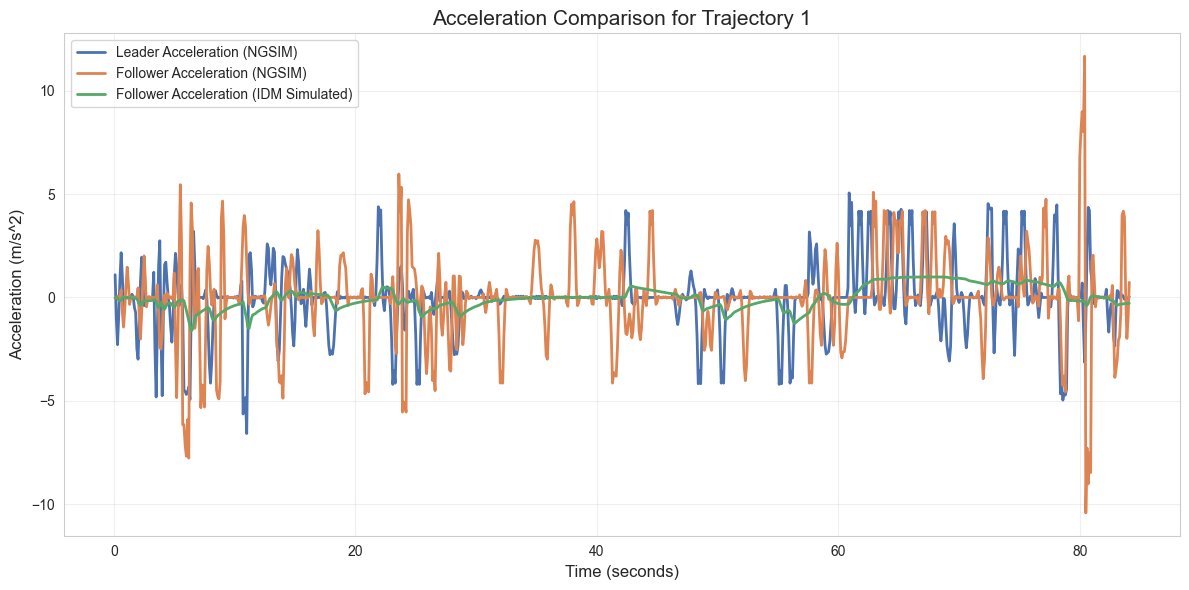

In [23]:
# leader acceleration, real follower acceleration, simulated follower acceleration

plt.figure(figsize=(12,6))
plt.plot(time_data, leader_a, linewidth=2, label='Leader Acceleration (NGSIM)')
plt.plot(time_data, real_follower_a, linewidth=2, label='Follower Acceleration (NGSIM)')
plt.plot(time_data, sim_acc, linewidth=2, label='Follower Acceleration (IDM Simulated)')

plt.title(f'Acceleration Comparison for Trajectory {trajectory_number}', fontsize=15)
plt.xlabel('Time (seconds)', fontsize=12)
plt.ylabel('Acceleration (m/s^2)', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()